<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Matrix Factorization for Movie Recommendations</b>
</h1>
<div style="font-family:'Times New Roman';">
This is the SVD idea showing up again. Instead of comparing users one by one, matrix factorization assumes every user and every movie can be described by a few hidden factors (like how much action vs romance), and a rating is just how well a users taste lines up with a movies factors. We learn these factors straight from the ratings.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The idea

We want to split the big ratings matrix R into two smaller ones:

**R ≈ P Q<sup>T</sup>**

where **P** holds a few hidden factors for each user and **Q** holds the same few factors for each movie. With k=2 factors you can imagine factor 1 being 'how action-y' and factor 2 being 'how romantic'. Its the same shape as SVD, the only twist is we only fit it on the ratings we actualy have, not the blanks.

In [2]:
# names for our users
names = ['Ayush', 'Akshay', 'Shad', 'Aditya', 'Rohan', 'Karan',
         'Manav', 'Dev', 'Arjun', 'Kabir', 'Veer', 'Nikhil']

movies = ['The Matrix', 'Inception', 'Mad Max', 'Terminator', 'Avengers',
          'Titanic', 'The Notebook', 'La La Land', 'Notting Hill', 'Pride and Prejudice',
          'Forrest Gump', 'Up', 'Interstellar', 'Gladiator', 'Toy Story']

# each movie has a hidden [action, romance] strength
movie_genre = np.array([
    [1.0, 0.0], [0.9, 0.1], [1.0, 0.0], [0.95, 0.0], [0.85, 0.15],
    [0.1, 1.0], [0.0, 1.0], [0.2, 0.9], [0.1, 0.95], [0.0, 1.0],
    [0.3, 0.6], [0.2, 0.5], [0.8, 0.3], [0.9, 0.2], [0.3, 0.4]])

rng = np.random.default_rng(1)
user_taste = rng.random((12, 2))               # each user likes action/romance to some degree

raw = user_taste @ movie_genre.T
R_true = np.clip(np.round(1 + 4 * raw / raw.max() + rng.normal(0, 0.3, raw.shape)), 1, 5)

# hide about 40% of the ratings, those are the ones we test on
mask = (rng.random(R_true.shape) < 0.6).astype(float)   # 1 = observed
R = R_true * mask
print('users x movies:', R.shape, ' observed fraction:', round(mask.mean(), 2))

users x movies: (12, 15)  observed fraction: 0.64


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Learning the factors with gradient descent</b>
</h2>
<div style="font-family:'Times New Roman';">
We start P and Q as random little numbers and nudge them so P Q<sup>T</sup> gets close to the ratings we *do* have. The error is only measured on observed cells (the mask handles that), and a small reg term keeps the numbers from blowing up.
</div>

In [9]:
def train_mf(R, mask, k=2, steps=3000, lr=0.01, reg=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n_users, n_movies = R.shape
    P = rng.normal(0, 0.1, (n_users, k))
    Q = rng.normal(0, 0.1, (n_movies, k))

    history = []
    for step in range(steps):
        E = mask * (R - P @ Q.T)            # error on observed cells only
        P += lr * (E @ Q - reg * P)
        Q += lr * (E.T @ P - reg * Q)
        if step % 200 == 0:
            history.append(np.sqrt((E ** 2).sum() / mask.sum()))
    return P, Q, history

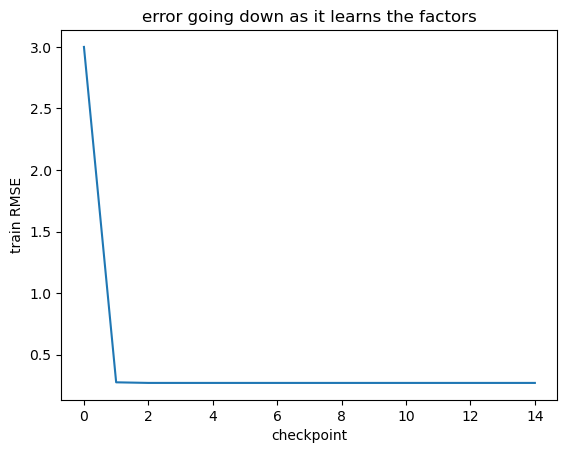

start RMSE: 3.0  end RMSE: 0.27


In [4]:
P, Q, history = train_mf(R, mask)

plt.plot(history)
plt.xlabel('checkpoint')
plt.ylabel('train RMSE')
plt.title('error going down as it learns the factors')
plt.show()
print('start RMSE:', round(history[0], 2), ' end RMSE:', round(history[-1], 2))

## Did it actually learn anything?

The real test is the ratings we hid. If the predicted values on those held out cells are close to the true ratings, it means the factors captured something real and not just memorised the training cells.

In [5]:
pred = P @ Q.T
held_out = (1 - mask).astype(bool)
rmse = np.sqrt(((R_true - pred)[held_out] ** 2).mean())
print('held out RMSE:', round(rmse, 2), ' (on a 1 to 5 scale)')

held out RMSE: 0.61  (on a 1 to 5 scale)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Recommending movies</b>
</h2>
<div style="font-family:'Times New Roman';">
Now the payoff. Lets look at the movies the model predicts each user would rate highest. The NEW tag marks the ones they havent rated yet, so those are the actual recommendations. I'll grab one clear action fan and one clear romance fan and see what floats to the top for each.
</div>

In [6]:
def top_predicted(u, n=5):
    order = np.argsort(pred[u])[::-1][:n]            # highest predicted first
    out = []
    for i in order:
        tag = 'already seen' if mask[u, i] else 'NEW'
        out.append((movies[i], round(float(pred[u, i]), 1), tag))
    return out

action_fan = int(np.argmax(user_taste[:, 0] - user_taste[:, 1]))
romance_fan = int(np.argmax(user_taste[:, 1] - user_taste[:, 0]))

print(f'{names[action_fan]} (action fan), top predicted:')
for m, r, tag in top_predicted(action_fan):
    print(f'   {m:22} {r}  ({tag})')

print(f'\n{names[romance_fan]} (romance fan), top predicted:')
for m, r, tag in top_predicted(romance_fan):
    print(f'   {m:22} {r}  ({tag})')

Rohan (action fan), top predicted:
   Inception              3.2  (already seen)
   Gladiator              3.0  (already seen)
   Avengers               3.0  (already seen)
   Mad Max                3.0  (already seen)
   Terminator             2.9  (already seen)

Akshay (romance fan), top predicted:
   The Notebook           5.2  (already seen)
   Titanic                4.7  (already seen)
   Pride and Prejudice    4.5  (already seen)
   Notting Hill           4.3  (already seen)
   La La Land             4.2  (already seen)


### what i learned here

- matrix factorization describes each user and movie with a few hidden factors, same idea as SVD
- you learn P and Q by gradient descent, only using the ratings that actualy exist
- it predicted the hidden ratings within about half a star, so the factors are real
- the action fan got action movies and the romance fan got romance ones, without me ever telling it the genres

and thats recommender systems, from the user item matrix idea, to plain collaborative filtering, to matrix factorization that quietly rediscovers the genres on its own.